In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import(
          accuracy_score,
          precision_score,
          recall_score,
          f1_score,
)

In [47]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

In [48]:
X_train_text = train_data.data
y_train = train_data.target
X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [49]:
print("Training documents :", len(X_train_text))
print("Testing documents :", len(X_test_text))
print("Number of classes :", len(class_names))

Training documents : 11314
Testing documents : 7532
Number of classes : 20


In [50]:
vectorizer = CountVectorizer(
       stop_words="english",
      min_df =2
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [51]:
print("Training feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [52]:
mnb = MultinomialNB()
mnb.fit(
       X_train,
       y_train
)
y_pred_mnb = mnb.predict(X_test)

In [53]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary = binary_vectorizer.fit_transform( X_train_text)
X_test_binary = binary_vectorizer.transform(X_test_text)

In [54]:
bnb = BernoulliNB()
bnb.fit(X_train_binary,
        y_train
       )
y_pred_bnb = bnb.predict(X_test_binary)

In [55]:

results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
])

models=[
    ("Multi", mnb, y_pred_mnb),
    ("BNB", bnb, y_pred_bnb)
]

for name, model, pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred,average='weighted'),
        recall_score(y_test, pred,average='weighted'),
        f1_score(y_test, pred,average='weighted'),
    ]
print(results)

   Model  Accuracy  Precision    Recall  F1 Score
0  Multi  0.651089   0.642532  0.651089  0.629644
1    BNB  0.485130   0.627034  0.485130  0.480839


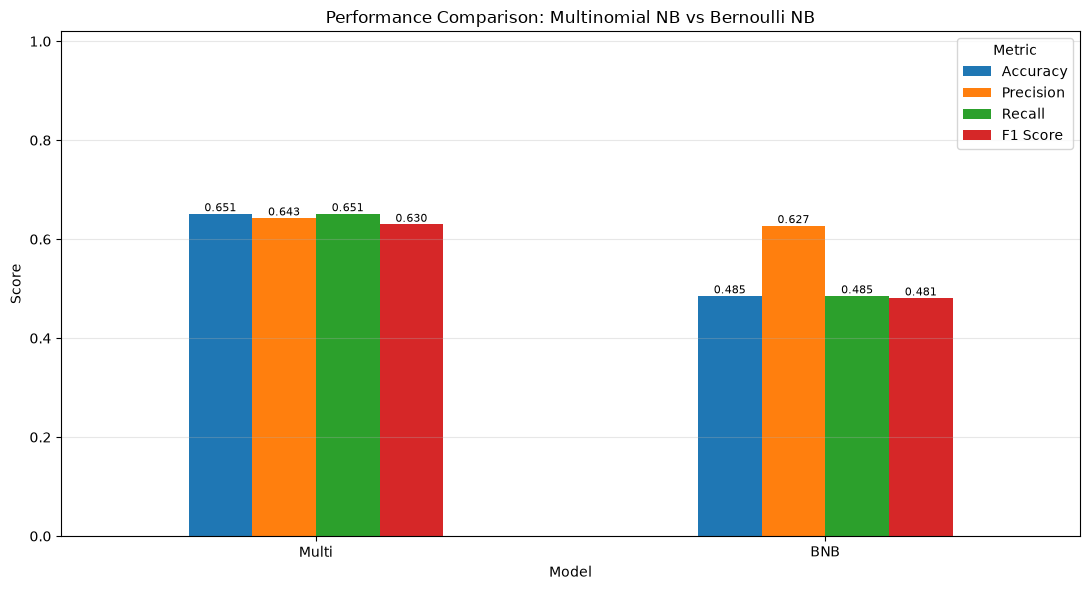

In [58]:
import matplotlib.pyplot as plt

results_metrics = results[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Performance Comparison: Multinomial  vs Bernoulli ")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()
plt.show()